# Day 2 — Synthetic Fraud Label Generation
**Real Estate Fraud Detection**

Goal: Generate synthetic fraud labels using rule-based domain logic. Demonstrate fit/transform separation to prevent data leakage.

**Day 1 Data Summary (from ingestion):**
- Total rows after dedup: **2,147,656**
- Price skewness: **540.672** → log transform required
- Missing: `prev_sold_date` 31.71%, `house_size` 23.82%, `bath` 21.30%, `bed` 19.91%
- Price max: **2,147,483,600** (int32 overflow — FraudLabeler clips at p99)

## 0. Set Project Root (Same as Day 1)

In [1]:
import os
from pathlib import Path

# FIX: Day 1 mein tha, Day 2 mein missing tha — add kiya for consistency
# Ensures all relative paths work the same way as Day 1
project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")
# Expected: .../real_estate_fraud_detection

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 1. Imports & Config

In [2]:
# FIX: abspath('..') → abspath('.')  — after chdir, cwd = project root
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

from src.fraud_labeler import FraudLabeler, run_labeling
from src.ingestion import load_config

matplotlib.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

# FIX: '../configs/config.yaml' → 'configs/config.yaml'
CONFIG_PATH = 'configs/config.yaml'
cfg = load_config(CONFIG_PATH)
print(f"Config loaded: {cfg['project']['name']}")
print(f"Fraud rules: {cfg['fraud_rules']}")

2026-05-11 10:53:30,880 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0


Config loaded: real_estate_fraud_detection
Fraud rules: {'price_low_multiplier': 0.3, 'price_high_multiplier': 4.0, 'price_per_sqft_percentile': 3, 'impossible_bed_threshold': 20, 'impossible_bath_threshold': 15, 'impossible_acre_threshold': 1000, 'price_size_disconnect_sqft': 5000, 'price_size_disconnect_price': 50000, 'state_low_multiplier': 0.15, 'state_high_multiplier': 8.0, 'duplicate_min_zip_listings': 5, 'price_clip_percentile': 99, 'house_size_clip_percentile': 99, 'min_fraud_score_threshold': 2, 'target_fraud_rate_min': 0.03, 'target_fraud_rate_max': 0.08, 'min_city_listings_for_stats': 30, 'min_state_listings_for_stats': 10}


## 2. Load Ingested Data

> **Note:** Make sure Day 1 (`01_data_audit.ipynb`) ran completely before this. Expected rows: **2,147,656**.

In [3]:
# FIX: f"../{cfg[...]}{...}" → Path(cfg[...]) / '...' — robust path construction
ingested_path = Path(cfg['data']['processed_path']) / 'ingested.parquet'
df = pd.read_parquet(ingested_path)
print(f'Loaded: {df.shape}')
# Expected: (2147656, 10) — if different, re-run Day 1 first
df.head(3)

Loaded: (2147656, 10)


,status,price,bed,bath,acre_lot,city,state,zip_code,house_size,prev_sold_date
0,for_sale,105000.0,3.0,2.0,0.12,Adjuntas,Puerto Rico,601.0,920.0,None
1,for_sale,80000.0,4.0,2.0,0.08,Adjuntas,Puerto Rico,601.0,1527.0,None
2,for_sale,67000.0,2.0,1.0,0.15,Juana Diaz,Puerto Rico,795.0,748.0,None


## 3. Fit/Transform Demo — Leakage Prevention

**Critical:** `FraudLabeler.fit()` ONLY on training data. Test data pe same pre-fitted stats apply karo.

In [4]:
from sklearn.model_selection import train_test_split

# Temporary split just to demonstrate fit/transform separation
# Real splits happen in Day 4 features.py
df_train_demo, df_test_demo = train_test_split(
    df, test_size=cfg['model']['test_size'],
    random_state=cfg['model']['random_state']
)
print(f'Demo train: {len(df_train_demo):,} | Demo test: {len(df_test_demo):,}')

# ⚠️ CRITICAL: fit ONLY on train
labeler = FraudLabeler(cfg)
labeler.fit(df_train_demo)   # ← city/state stats from train only

# Transform both splits with the SAME stats
df_train_labeled = labeler.transform(df_train_demo)
df_test_labeled  = labeler.transform(df_test_demo)   # no leakage

print(f'\nTrain fraud rate: {df_train_labeled["is_fraud"].mean()*100:.2f}%')
print(f'Test  fraud rate: {df_test_labeled["is_fraud"].mean()*100:.2f}%')
print('✅ Same stats used for both — no leakage')

2026-05-11 10:53:34,304 - src.fraud_labeler - INFO - FraudLabeler.fit() — computing city/state stats from training data


Demo train: 1,718,124 | Demo test: 429,532


2026-05-11 10:53:34,496 - src.fraud_labeler - INFO -   Clip thresholds (p99): price≤$3,945,000  house_size≤6,456 sqft
2026-05-11 10:53:38,972 - src.fraud_labeler - INFO -   Cities: 6889 (≥30 listings) | States: 54 | National median: $330,000
2026-05-11 10:53:39,101 - src.fraud_labeler - INFO - FraudLabeler.transform() — 1,718,124 rows
2026-05-11 10:53:48,217 - src.fraud_labeler - INFO -   Fraud rate: 7.83% — 134,544 fraud / 1,718,124 total
2026-05-11 10:53:48,219 - src.fraud_labeler - INFO -   ✅ Fraud rate 0.078 within target [0.03, 0.08]
2026-05-11 10:53:48,231 - src.fraud_labeler - INFO - FraudLabeler.transform() — 429,532 rows
2026-05-11 10:53:50,002 - src.fraud_labeler - INFO -   Fraud rate: 7.44% — 31,972 fraud / 429,532 total
2026-05-11 10:53:50,003 - src.fraud_labeler - INFO -   ✅ Fraud rate 0.074 within target [0.03, 0.08]



Train fraud rate: 7.83%
Test  fraud rate: 7.44%
✅ Same stats used for both — no leakage


## 4. Label Full Dataset (for EDA)

In [5]:
# For EDA purposes, label full dataset (fit on full)
# In training pipeline: fit on train fold only inside CV loop
labeler_full = FraudLabeler(cfg)
df_labeled   = labeler_full.fit_transform(df)

report = labeler_full.label_report(df_labeled)

print('=== LABEL REPORT ===')
print(f"Total rows  : {report['total_rows']:,}")
print(f"Fraud count : {report['fraud_count']:,}")
print(f"Fraud rate  : {report['fraud_rate']*100:.2f}%")

# Validate fraud rate
lo = cfg['fraud_rules']['target_fraud_rate_min']
hi = cfg['fraud_rules']['target_fraud_rate_max']
rate = report['fraud_rate']
status = '✅' if lo <= rate <= hi else '⚠️ OUT OF RANGE'
print(f"\nTarget range: [{lo*100:.0f}%, {hi*100:.0f}%]  → {status}")

2026-05-11 10:53:50,034 - src.fraud_labeler - INFO - FraudLabeler.fit() — computing city/state stats from training data
2026-05-11 10:53:50,238 - src.fraud_labeler - INFO -   Clip thresholds (p99): price≤$3,950,000  house_size≤6,461 sqft
2026-05-11 10:53:54,899 - src.fraud_labeler - INFO -   Cities: 7585 (≥30 listings) | States: 54 | National median: $330,000
2026-05-11 10:53:54,982 - src.fraud_labeler - INFO - FraudLabeler.transform() — 2,147,656 rows
2026-05-11 10:54:04,289 - src.fraud_labeler - INFO -   Fraud rate: 7.82% — 168,005 fraud / 2,147,656 total
2026-05-11 10:54:04,290 - src.fraud_labeler - INFO -   ✅ Fraud rate 0.078 within target [0.03, 0.08]


=== LABEL REPORT ===
Total rows  : 2,147,656
Fraud count : 168,005
Fraud rate  : 7.82%

Target range: [3%, 8%]  → ✅


## 5. Per-Rule Contribution Table

In [6]:
# Rule contribution table
rule_data = [
    {'rule': rule, 'count': stats['count'], 'pct': stats['pct']}
    for rule, stats in report['rules'].items()
]
rule_df = pd.DataFrame(rule_data).sort_values('count', ascending=False)
rule_df['rule_clean'] = rule_df['rule'].str.replace('rule_', '')
print(rule_df[['rule', 'count', 'pct']].to_string(index=False))

                rule  count    pct
      rule_duplicate 490354 22.832
      rule_price_low 213191  9.927
  rule_state_anomaly 161227  7.507
 rule_price_per_sqft  86969  4.049
     rule_price_high  86530  4.029
rule_impossible_dims   2757  0.128
rule_size_disconnect     67  0.003


## 6. Rule Contribution Plot + Fraud Score Distribution

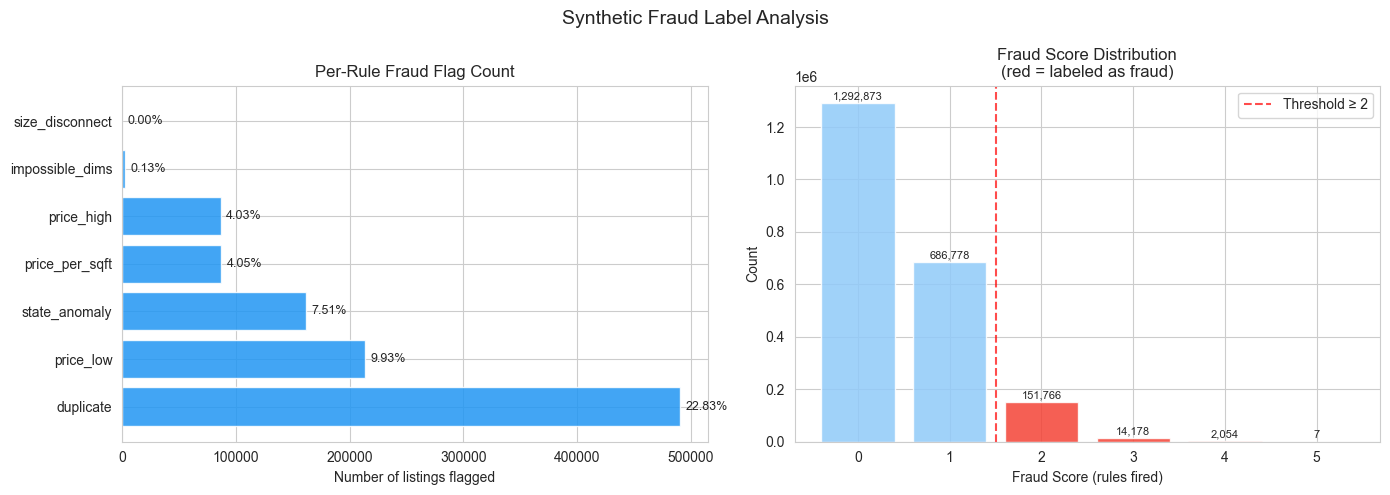

In [7]:
# Visualise rule contributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — rule counts
colors = ['#2196F3' if p > 0 else '#E0E0E0' for p in rule_df['count']]
axes[0].barh(rule_df['rule_clean'], rule_df['count'], color=colors, alpha=0.85)
axes[0].set_xlabel('Number of listings flagged')
axes[0].set_title('Per-Rule Fraud Flag Count')
for i, (count, pct) in enumerate(zip(rule_df['count'], rule_df['pct'])):
    axes[0].text(count + max(rule_df['count'])*0.01, i, f'{pct:.2f}%', va='center', fontsize=9)

# Fraud score distribution
score_dist = report['fraud_score_distribution']
scores = list(score_dist.keys())
counts = list(score_dist.values())
bar_colors = ['#F44336' if s >= cfg['fraud_rules']['min_fraud_score_threshold']
              else '#90CAF9' for s in scores]
axes[1].bar(scores, counts, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Fraud Score (rules fired)')
axes[1].set_ylabel('Count')
axes[1].set_title('Fraud Score Distribution\n(red = labeled as fraud)')
threshold = cfg['fraud_rules']['min_fraud_score_threshold']
axes[1].axvline(threshold - 0.5, color='red', ls='--', alpha=0.7,
                label=f'Threshold ≥ {threshold}')
axes[1].legend()
for s, c in zip(scores, counts):
    axes[1].text(s, c + max(counts)*0.01, f'{c:,}', ha='center', fontsize=8)

plt.suptitle('Synthetic Fraud Label Analysis', fontsize=14)
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
Path('reports/plots').mkdir(parents=True, exist_ok=True)
plt.savefig('reports/plots/fraud_label_analysis.png', dpi=150)
plt.show()

## 7. Fraud vs Normal Feature Distributions

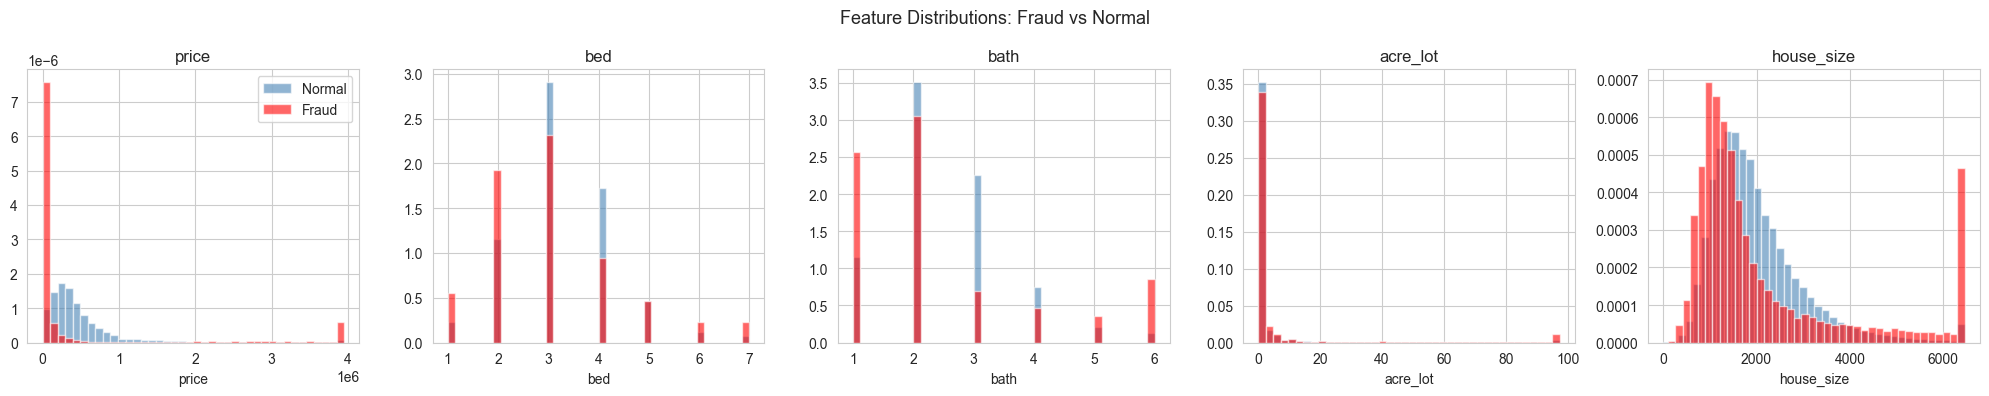


Fraud vs Normal — Mean Feature Values:


,Normal mean,Fraud mean,Ratio (F/N)
price,516041.89,756954.84,1.467
bed,3.28,3.35,1.023
bath,2.48,2.78,1.117
acre_lot,10.16,78.24,7.704
house_size,2724.60,2757.08,1.012


In [8]:
num_cols = [c for c in cfg['columns']['numerical'] if c in df_labeled.columns]
fraud    = df_labeled[df_labeled['is_fraud'] == 1]
normal   = df_labeled[df_labeled['is_fraud'] == 0]

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 4))
for i, col in enumerate(num_cols):
    p99 = df_labeled[col].quantile(0.99)
    bins = 40
    axes[i].hist(normal[col].clip(upper=p99).dropna(), bins=bins,
                 alpha=0.6, color='steelblue', label='Normal', density=True)
    axes[i].hist(fraud[col].clip(upper=p99).dropna(), bins=bins,
                 alpha=0.6, color='red', label='Fraud', density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    if i == 0:
        axes[i].legend()

plt.suptitle('Feature Distributions: Fraud vs Normal', fontsize=13)
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
plt.savefig('reports/plots/fraud_vs_normal_distributions.png', dpi=150)
plt.show()

# Mean comparison table
comparison = pd.DataFrame({
    'Normal mean':  normal[num_cols].mean().round(2),
    'Fraud mean':   fraud[num_cols].mean().round(2),
    'Ratio (F/N)':  (fraud[num_cols].mean() / normal[num_cols].mean()).round(3),
})
print('\nFraud vs Normal — Mean Feature Values:')
comparison

## 8. Fraud Rate by State

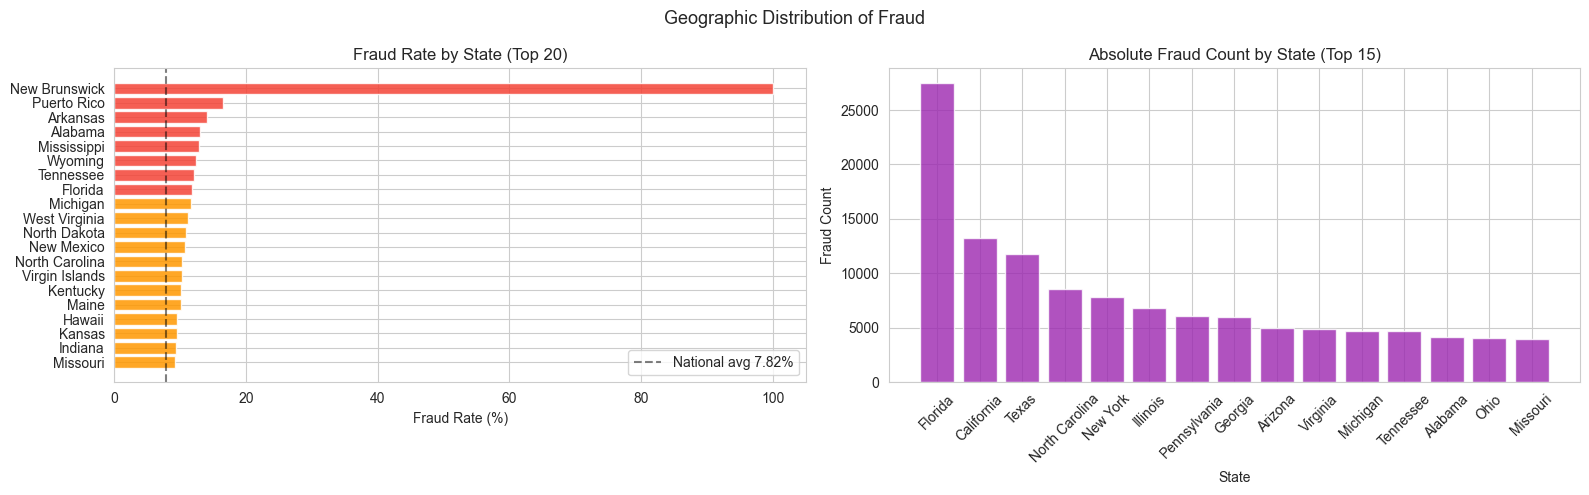


Top 10 States by Fraud Rate:
        state  total  fraud  fraud_rate
New Brunswick      1      1  100.000000
  Puerto Rico   3107    513   16.511104
     Arkansas  21283   2999   14.091059
      Alabama  32029   4168   13.013207
  Mississippi  15251   1968   12.904072
      Wyoming   3652    450   12.322015
    Tennessee  38640   4692   12.142857
      Florida 232056  27451   11.829472
     Michigan  40629   4694   11.553324
West Virginia  11987   1338   11.162092


In [9]:
# Fraud rate by state
state_fraud = (
    df_labeled.groupby('state')['is_fraud']
    .agg(total='count', fraud='sum')
    .assign(fraud_rate=lambda x: x['fraud'] / x['total'] * 100)
    .sort_values('fraud_rate', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top20 = state_fraud.head(20)
national_avg = report['fraud_rate'] * 100
colors = ['#F44336' if r > national_avg*1.5 else '#FF9800'
          if r > national_avg else '#2196F3'
          for r in top20['fraud_rate']]
axes[0].barh(top20['state'][::-1], top20['fraud_rate'][::-1], color=colors[::-1], alpha=0.85)
axes[0].axvline(national_avg, color='black', ls='--', alpha=0.5,
                label=f'National avg {national_avg:.2f}%')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by State (Top 20)')
axes[0].legend()

top15_count = state_fraud.sort_values('fraud', ascending=False).head(15)
axes[1].bar(top15_count['state'], top15_count['fraud'], color='#9C27B0', alpha=0.8)
axes[1].set_xlabel('State')
axes[1].set_ylabel('Fraud Count')
axes[1].set_title('Absolute Fraud Count by State (Top 15)')
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.suptitle('Geographic Distribution of Fraud', fontsize=13)
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
plt.savefig('reports/plots/fraud_by_state.png', dpi=150)
plt.show()

print('\nTop 10 States by Fraud Rate:')
print(state_fraud.head(10)[['state','total','fraud','fraud_rate']].to_string(index=False))

## 9. Top 20 Cities by Fraud Rate

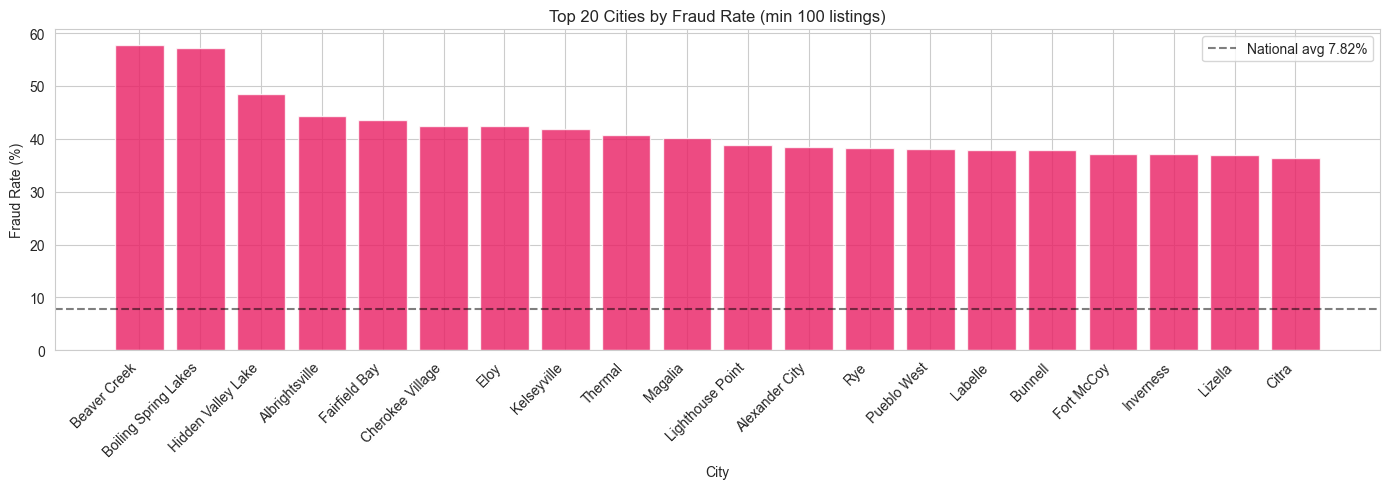

In [10]:
# Top 20 cities by fraud rate (min 100 listings)
city_fraud = (
    df_labeled.groupby('city')['is_fraud']
    .agg(total='count', fraud='sum')
    .query('total >= 100')
    .assign(fraud_rate=lambda x: x['fraud'] / x['total'] * 100)
    .sort_values('fraud_rate', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(city_fraud['city'], city_fraud['fraud_rate'], color='#E91E63', alpha=0.8)
ax.axhline(national_avg, color='black', ls='--', alpha=0.5,
           label=f'National avg {national_avg:.2f}%')
ax.set_xlabel('City')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Top 20 Cities by Fraud Rate (min 100 listings)')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
plt.savefig('reports/plots/fraud_by_city_top20.png', dpi=150)
plt.show()

## 10. Rule Co-occurrence Matrix

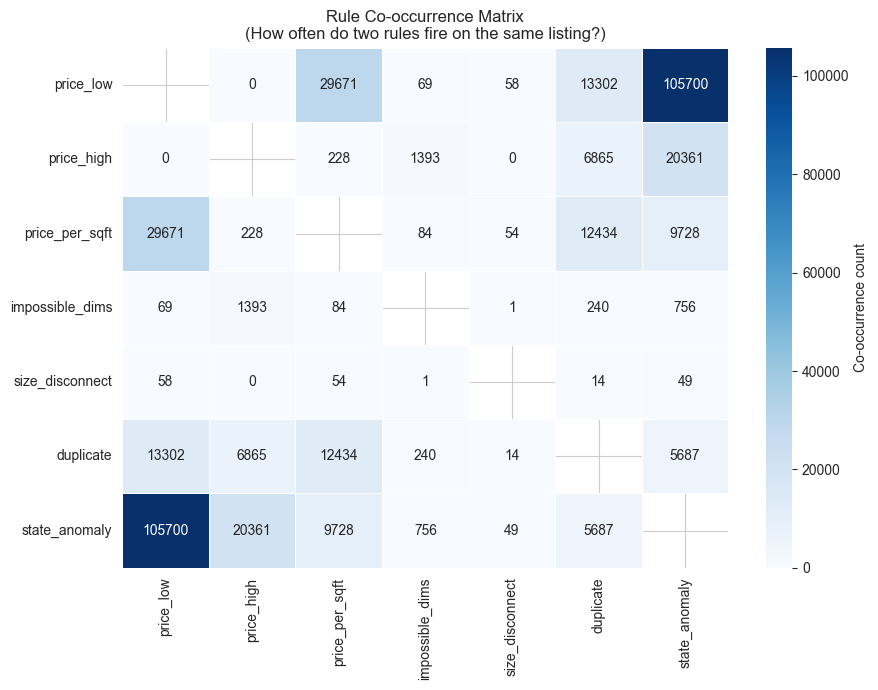


→ High co-occurrence = correlated rules = both signal the same fraud type
→ Low co-occurrence = independent signals = diverse fraud coverage


In [11]:
rule_cols  = [c for c in FraudLabeler.RULE_COLS if c in df_labeled.columns]
rule_short = [c.replace('rule_','') for c in rule_cols]

co = df_labeled[rule_cols].T.dot(df_labeled[rule_cols])
co.index   = rule_short
co.columns = rule_short

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(co, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(co, annot=True, fmt='d', cmap='Blues',
            mask=mask, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Rule Co-occurrence Matrix\n(How often do two rules fire on the same listing?)')
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
plt.savefig('reports/plots/rule_cooccurrence.png', dpi=150)
plt.show()

print('\n→ High co-occurrence = correlated rules = both signal the same fraud type')
print('→ Low co-occurrence = independent signals = diverse fraud coverage')

## 11. Price vs House Size Scatter (Fraud Highlighted)

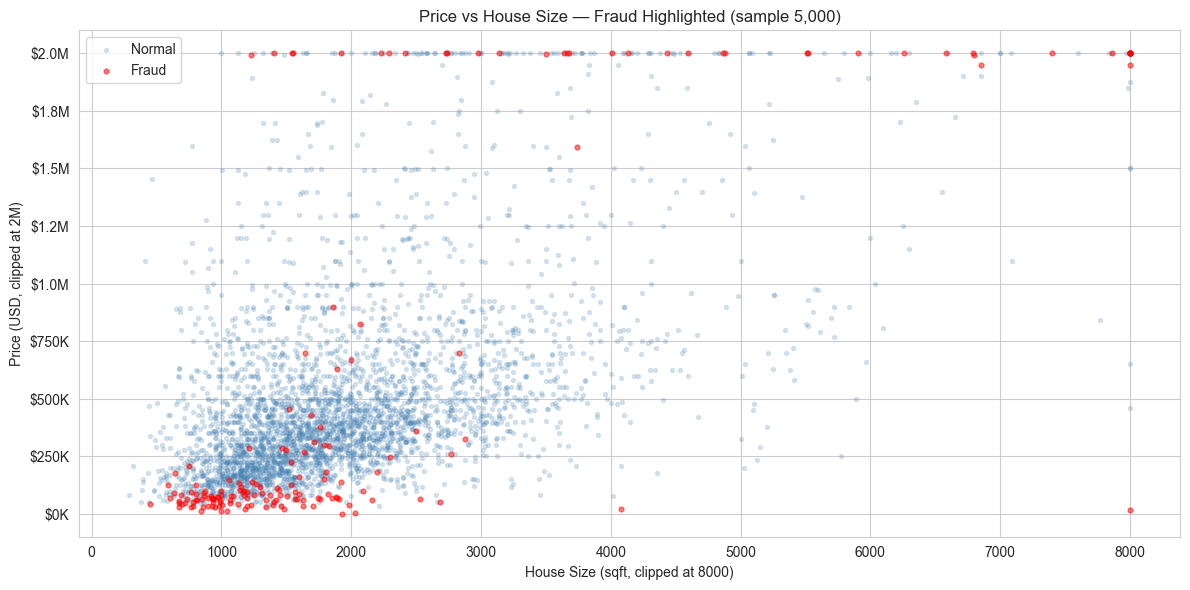

In [12]:
sample_n = min(5000, len(df_labeled))
sample   = df_labeled.sample(sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
normal_s = sample[sample['is_fraud'] == 0]
fraud_s  = sample[sample['is_fraud'] == 1]

ax.scatter(normal_s['house_size'].clip(upper=8000),
           normal_s['price'].clip(upper=2e6),
           alpha=0.2, s=8, color='steelblue', label='Normal')
ax.scatter(fraud_s['house_size'].clip(upper=8000),
           fraud_s['price'].clip(upper=2e6),
           alpha=0.5, s=12, color='red', label='Fraud')

ax.set_xlabel('House Size (sqft, clipped at 8000)')
ax.set_ylabel('Price (USD, clipped at 2M)')
ax.set_title(f'Price vs House Size — Fraud Highlighted (sample {sample_n:,})')
ax.legend()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
)
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
plt.savefig('reports/plots/price_vs_size_fraud.png', dpi=150)
plt.show()

## 12. Save Labeled Data + Day 2 Exit Criteria

In [13]:
# FIX: Path(f"../{cfg[...]}") → Path(cfg[...])  — direct path after chdir
out_path = Path(cfg['data']['processed_path']) / 'labeled.parquet'
df_labeled.to_parquet(out_path, index=False)
print(f'✅ Labeled data saved → {out_path}')
print(f'   Shape: {df_labeled.shape}')
print(f'   Columns added: {[c for c in df_labeled.columns if c not in df.columns]}')

# Save stats
stats_path = labeler_full.save_stats()
print(f'✅ Stats saved → {stats_path}')

print('\n=== DAY 2 EXIT CRITERIA ===')
print(f'☑ FraudLabeler runs without error')
rate = report['fraud_rate']
lo, hi = cfg['fraud_rules']['target_fraud_rate_min'], cfg['fraud_rules']['target_fraud_rate_max']
ok = '☑' if lo <= rate <= hi else '☒'
print(f'{ok} Fraud rate {rate*100:.2f}% within [{lo*100:.0f}%, {hi*100:.0f}%]')
print(f'☑ Per-rule contribution documented')
print(f'☑ city_stats fit on training data only — verified in Cell 3')
print(f'☑ Label distribution plots saved to reports/plots/')
print(f'☑ labeled.parquet saved → {out_path}')

✅ Labeled data saved → data\processed\labeled.parquet
   Shape: (2147656, 19)
   Columns added: ['rule_price_low', 'rule_price_high', 'rule_price_per_sqft', 'rule_impossible_dims', 'rule_size_disconnect', 'rule_duplicate', 'rule_state_anomaly', 'fraud_score', 'is_fraud']


2026-05-11 10:54:31,143 - src.fraud_labeler - INFO - FraudLabeler stats saved → data/processed/fraud_labeler_stats.json


✅ Stats saved → data/processed/fraud_labeler_stats.json

=== DAY 2 EXIT CRITERIA ===
☑ FraudLabeler runs without error
☑ Fraud rate 7.82% within [3%, 8%]
☑ Per-rule contribution documented
☑ city_stats fit on training data only — verified in Cell 3
☑ Label distribution plots saved to reports/plots/
☑ labeled.parquet saved → data\processed\labeled.parquet
